In [49]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import subprocess


In [47]:
csec_vcf = "/home/tilman/termites/csec_prdm9/data/Csec_concat_geq1000_rm_indels_hard_filt_excesshet.vcf_biallelic_dpfilt_qualfilt_no_mac_maxmiss06_rmfilt_MQ70_dp2stdev.recode.vcf"
mbel_vcf = '/home/tilman/termites/REVISIONS/missingness/Mbel_concat_excl5scaffolds_rm_indels_hard_filt_excesshet.vcf_biallelic_dpfilt_qualfilt_no_mac_maxmiss06_rmfilt_MQ70_dp2stdev.recode.vcf'
#mbel_vcf = "/home/tilman/termites/mbel_prdm9_vcf/Mbel_concat_excl5scaffolds_rm_indels_hard_filt_excesshet.vcf_biallelic_dpfilt_qualfilt_mac2_maxmiss06_rmfilt.recode.vcf_sedmissing_ph_imp.vcf_MQ70_depth2stdev_v4.recode.vcf.gz"

In [12]:
def run_vcftools(vcf_file, output_prefix):
    # Run vcftools to get individual missingness
    if vcf_file.endswith(".vcf"):
        input_flag = '--vcf'
    elif vcf_file.endswith(".vcf.gz"):
        input_flag = '--gzvcf'
    else:
        raise IOError("the fileformat is not either vcf or vcf.gz")
    subprocess.run([
        "vcftools", input_flag, vcf_file, "--missing-indv", "--out", output_prefix
    ], check=True)

    # Run vcftools to get site missingness
    subprocess.run([
        "vcftools", input_flag, vcf_file, "--missing-site", "--out", output_prefix
    ], check=True)

In [14]:
run_vcftools(vcf_file=csec_vcf, output_prefix="csec_")

In [48]:
run_vcftools(vcf_file=mbel_vcf, output_prefix="mbel")


VCFtools - 0.1.17
(C) Adam Auton and Anthony Marcketta 2009

Parameters as interpreted:
	--vcf /home/tilman/termites/REVISIONS/missingness/Mbel_concat_excl5scaffolds_rm_indels_hard_filt_excesshet.vcf_biallelic_dpfilt_qualfilt_no_mac_maxmiss06_rmfilt_MQ70_dp2stdev.recode.vcf
	--missing-indv
	--out mbel

After filtering, kept 10 out of 10 Individuals
Outputting Individual Missingness
After filtering, kept 5581662 out of a possible 5581662 Sites
Run Time = 20.00 seconds

VCFtools - 0.1.17
(C) Adam Auton and Anthony Marcketta 2009

Parameters as interpreted:
	--vcf /home/tilman/termites/REVISIONS/missingness/Mbel_concat_excl5scaffolds_rm_indels_hard_filt_excesshet.vcf_biallelic_dpfilt_qualfilt_no_mac_maxmiss06_rmfilt_MQ70_dp2stdev.recode.vcf
	--out mbel
	--missing-site

After filtering, kept 10 out of 10 Individuals
Outputting Site Missingness
After filtering, kept 5581662 out of a possible 5581662 Sites
Run Time = 33.00 seconds


In [50]:

def parse_missingness_files(output_prefix):
    # Parse individual missingness
    individual_missingness_file = f"{output_prefix}.imiss"
    indv_missing_df = pd.read_csv(individual_missingness_file, delim_whitespace=True)

    # Parse site missingness
    site_missingness_file = f"{output_prefix}.lmiss"
    site_missing_df = pd.read_csv(site_missingness_file, delim_whitespace=True)

    return indv_missing_df, site_missing_df


In [51]:
mbel_imiss, mbel_smiss = parse_missingness_files('mbel')

In [52]:
csec_imiss, csec_smiss = parse_missingness_files('csec_')

In [28]:
#?sns.scatterplot

In [31]:
[0 for i in csec_imiss.F_MISS]

[0, 0, 0, 0, 0, 0, 0, 0, 0]

In [53]:
[list(csec_imiss.F_MISS), list(mbel_imiss.F_MISS)]

[[5.5661e-05,
  2.54697e-05,
  4.62844e-05,
  2.36742e-05,
  9.54283e-05,
  2.64007e-05,
  7.33501e-05,
  3.71073e-05,
  2.06817e-05],
 [8.67125e-05,
  0.000142968,
  0.000192774,
  8.2771e-05,
  7.13049e-05,
  0.000153718,
  0.000118603,
  9.42372e-05,
  0.000123798,
  0.000115915]]

In [66]:
mbel_imiss.F_MISS.std()
mbel_imiss.F_MISS.mean()

3.725730873987307e-05

In [78]:
mbel_smiss

,CHR,POS,N_DATA,N_GENOTYPE_FILTERED,N_MISS,F_MISS
0,scaffold100,100026,20,0,0,0.0
1,scaffold100,100170,20,0,0,0.0
2,scaffold100,101384,20,0,0,0.0
3,scaffold100,101709,20,0,0,0.0
4,scaffold100,101928,20,0,0,0.0
...,...,...,...,...,...,...
5581657,scaffold9,33799029,20,0,0,0.0
5581658,scaffold9,33799122,20,0,0,0.0
5581659,scaffold9,33799600,20,0,0,0.0
5581660,scaffold9,33799718,20,0,0,0.0


In [75]:
mbel_smiss.shape

(5581662, 6)

In [76]:
csec_smiss.shape

(15037468, 6)

In [69]:
#csec_imiss.F_MISS.std()
csec_imiss.F_MISS.mean()

4.489526666666667e-05

In [71]:
csec_smiss.F_MISS.std()

0.001754824268752467

In [74]:
mbel_smiss.F_MISS.mean()

8.286922178376262e-05

<Axes: ylabel='Count'>

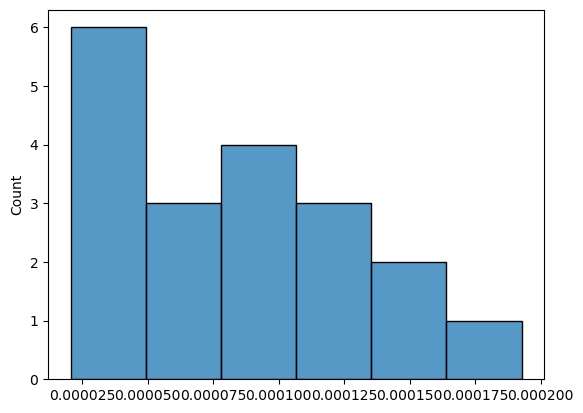

In [55]:
sns.histplot(list(csec_imiss.F_MISS)+list(mbel_imiss.F_MISS))

<Axes: xlabel='F_MISS', ylabel='Density'>

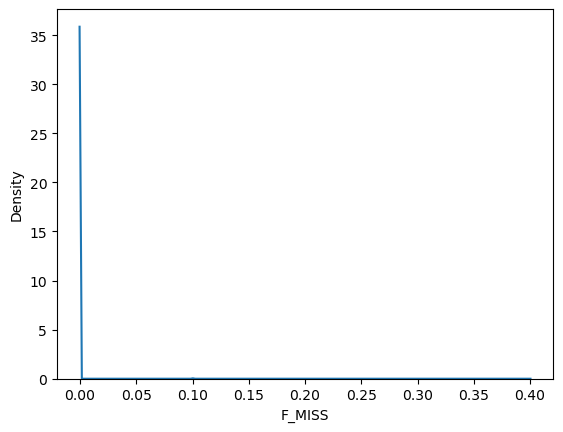

In [62]:
sns.kdeplot(mbel_smiss.F_MISS)

In [ ]:

def parse_missingness_files(output_prefix):
    # Parse individual missingness
    individual_missingness_file = f"{output_prefix}.imiss"
    indv_missing_df = pd.read_csv(individual_missingness_file, delim_whitespace=True)

    # Parse site missingness
    site_missingness_file = f"{output_prefix}.lmiss"
    site_missing_df = pd.read_csv(site_missingness_file, delim_whitespace=True)

    return indv_missing_df, site_missing_df

def main():
    vcf_file = "input.vcf"  # Replace with your VCF file path
    output_prefix = "output"  # Replace with your desired output prefix

    # Run vcftools to generate missingness files
    run_vcftools(vcf_file, output_prefix)

    # Parse the generated missingness files
    indv_missing_df, site_missing_df = parse_missingness_files(output_prefix)

    # Print individual missingness
    print("Individual Missingness:")
    print(indv_missing_df)